# Analisi modale di una piastra incastrata con l'elemento CQUAD4F

**Caso di prova:** piastra quadrata in **alluminio**, incastrata sui quattro lati (CCCC).

pyCAFE ha una sola formulazione di shell strutturale, il **`CQUAD4F`**
(`element_cquad4f.py`): elemento piano a 4 nodi, 6 gdl per nodo, in stile
MacNeal / MSC.Nastran — integrazione ridotta selettiva più la correzione di
**residual bending flexibility** per il taglio trasversale. L'implementazione
deriva da **py-polifemo**, un solutore FEM che sarà a breve rilasciato come
open source.

Qui se ne studia il comportamento modale al variare dei due parametri che ne
governano il taglio: `epsilon` (il coefficiente di miscelazione di MacNeal) e
`rbf_mindlin` (che aggiunge la flessibilità a taglio vera e propria).

### Cosa si misura
1. convergenza della prima frequenza al raffinare della mesh;
2. errore sui primi 10 modi su mesh fine;
3. forme modali e correlazione MAC fra due tarature di `epsilon`;
4. **sensibilità alla distorsione della mesh**;
5. comportamento al variare dello spessore (piastra sottile → moderatamente spessa).

---
## 1 — Import e impostazioni

In [1]:
import sys, os
from functools import partial

import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse.linalg import eigsh

# il notebook sta in examples/: assicura che la radice del repo sia importabile
if not os.path.isdir("pycafe"):
    sys.path.insert(0, os.path.abspath(".."))

from pycafe.build_matrices.assembly import assemble_KM
from pycafe.build_matrices.element_cquad4f import (
    EPSILON_DEFAULT, element_matrices_cquad4f)

plt.rcParams.update({"figure.dpi": 110, "font.size": 9,
                     "axes.grid": True, "grid.alpha": 0.3})
np.set_printoptions(precision=4, suppress=True)
print("pyCAFE pronto")

pyCAFE pronto


---
## 2 — Materiale e geometria

**Alluminio** (lega strutturale tipo 6061-T6):

| Proprietà | Simbolo | Valore |
|---|---|---|
| Modulo di Young | $E$ | 70 GPa |
| Coefficiente di Poisson | $\nu$ | 0.33 |
| Densità | $\rho$ | 2700 kg/m³ |

Piastra quadrata $a \times a = 1 \times 1$ m, spessore $t = 5$ mm
(rapporto $a/t = 200$: piastra **sottile**, quindi confrontabile con la teoria di Kirchhoff).

In [2]:
# --- materiale: alluminio
E   = 70.0e9     # Pa
NU  = 0.33       # -
RHO = 2700.0     # kg/m^3

# --- geometria
A  = 1.0         # lato della piastra [m]
TH = 0.005       # spessore [m]

D_flex = E * TH**3 / (12 * (1 - NU**2))          # rigidezza flessionale [N m]
print(f"Rigidezza flessionale D = {D_flex:.2f} N m")
print(f"Massa della piastra     = {RHO * TH * A * A:.2f} kg")
print(f"Rapporto a/t            = {A/TH:.0f}  (piastra sottile)")

Rigidezza flessionale D = 818.28 N m
Massa della piastra     = 13.50 kg
Rapporto a/t            = 200  (piastra sottile)


---
## 3 — Mesh e condizioni di vincolo (incastro)

La mesh è una griglia strutturata di quadrilateri a 4 nodi. Ogni nodo ha
**6 gradi di libertà**: `[ux, uy, uz, rx, ry, rz]`.

**Incastro (clamped):** su tutto il bordo si bloccano *tutti e sei* i gdl.
È la condizione più severa e, a differenza dell'appoggio, non ammette
soluzione analitica esatta: si usa la soluzione di Rayleigh–Ritz di Leissa.

In [3]:
def make_mesh(n, a=A):
    '''Griglia strutturata n x n di CQUAD4 su [0,a] x [0,a], z = 0.

    Restituisce (nodes (N,3), conn (n*n,4) 0-based).'''
    v = np.linspace(0.0, a, n + 1)
    X, Y = np.meshgrid(v, v, indexing="ij")
    nodes = np.column_stack([X.ravel(), Y.ravel(), np.zeros(X.size)])
    conn = np.array([[i * (n + 1) + j,
                      (i + 1) * (n + 1) + j,
                      (i + 1) * (n + 1) + j + 1,
                      i * (n + 1) + j + 1]
                     for i in range(n) for j in range(n)], dtype=int)
    return nodes, conn


def boundary_nodes(nodes, a=A, tol=1e-9):
    x, y = nodes[:, 0], nodes[:, 1]
    return (np.isclose(x, 0, atol=tol) | np.isclose(x, a, atol=tol)
            | np.isclose(y, 0, atol=tol) | np.isclose(y, a, atol=tol))


def clamped_free_dofs(nodes, a=A):
    '''Indici dei gdl liberi: incastro completo (6 gdl) sul bordo.'''
    edge = boundary_nodes(nodes, a)
    fixed = {6 * k + d for k in np.flatnonzero(edge) for d in range(6)}
    return np.array(sorted(set(range(6 * len(nodes))) - fixed), dtype=int)


nodes, conn = make_mesh(6)
free = clamped_free_dofs(nodes)
print(f"mesh 6x6 : {len(nodes)} nodi, {len(conn)} elementi, "
      f"{6*len(nodes)} gdl totali -> {len(free)} liberi dopo l'incastro")

mesh 6x6 : 49 nodi, 36 elementi, 294 gdl totali -> 150 liberi dopo l'incastro


---
## 4 — Le configurazioni a confronto

L'elemento è sempre lo stesso; cambiano solo i parametri, congelati con
`functools.partial`.

* **ε = 0.0227** — il valore di default (`EPSILON_DEFAULT`), quello
  dell'implementazione di riferimento.
* **ε = 0.0336** — il valore ottenuto tarando l'elemento sulla matrice di
  rigidezza di MSC.Nastran (vedi `cquad4_plate_validation.ipynb`).
* **ε = 0.10** — valore volutamente alto, per mostrare la sensibilità al
  parametro: ε più grande = correzione di flessibilità più forte = elemento
  più cedevole.
* **+Zs** (`rbf_mindlin=True`) — alla flessibilità residua $Z_b$ si somma
  quella di taglio $Z_s$: l'elemento smette di essere un elemento di piastra
  sottile e *sente* lo spessore (§11).

In [4]:
ELEMENTI = {
    "e=0.0227 (default)": dict(k=partial(element_matrices_cquad4f,
                                         epsilon=EPSILON_DEFAULT),
                               c="#2ca02c", ls="-"),
    "e=0.0336 (tarato)":  dict(k=partial(element_matrices_cquad4f, epsilon=0.0336),
                               c="#d62728", ls="-"),
    "e=0.10":             dict(k=partial(element_matrices_cquad4f, epsilon=0.10),
                               c="#9467bd", ls="-"),
    "e=0.0336 +Zs":       dict(k=partial(element_matrices_cquad4f, epsilon=0.0336,
                                         rbf_mindlin=True),
                               c="#ff7f0e", ls="--"),
}
print(len(ELEMENTI), "configurazioni:", *ELEMENTI, sep="\n  ")

4
  configurazioni:
  e=0.0227 (default)
  e=0.0336 (tarato)
  e=0.10
  e=0.0336 +Zs


---
## 5 — Il solutore modale

Si assemblano $K$ e $M$, si eliminano i gdl vincolati e si risolve il problema
agli autovalori generalizzato $K\phi = \omega^2 M \phi$.

**Nota numerica:** la matrice di massa non ha inerzia rotazionale, quindi
$M$ è singolare sui gdl di rotazione. Si usa quindi
`eigsh` in modalità *shift-invert* (`sigma=0`), che cerca gli autovalori più
vicini a zero e ignora quelli infiniti associati alla massa nulla.

In [5]:
def analisi_modale(kernel, nodes, conn, n_modi=10, t=TH, a=A):
    '''Frequenze [Hz] e forme modali (vettori globali) della piastra incastrata.'''
    K, M, _ = assemble_KM(nodes, conn, kernel, dofs_per_node=6,
                          kernel_args=(t, RHO, E, NU))
    free = clamped_free_dofs(nodes, a)
    vals, vecs = eigsh(K[np.ix_(free, free)].tocsc(), k=n_modi,
                       M=M[np.ix_(free, free)].tocsc(), sigma=0.0, which="LM")
    order = np.argsort(vals)
    freqs = np.sqrt(np.abs(vals[order])) / (2 * np.pi)
    Phi = np.zeros((6 * len(nodes), n_modi))
    Phi[free] = vecs[:, order]
    return freqs, Phi

---
## 6 — Soluzione di riferimento (Leissa)

Per la piastra quadrata incastrata su tutti i lati non esiste una soluzione in
forma chiusa. Il riferimento classico sono i coefficienti di Leissa
*(A. W. Leissa,* Vibration of Plates*, NASA SP-160, 1969)*, ottenuti per
Rayleigh–Ritz sulla teoria di **Kirchhoff** (piastra sottile, taglio trascurato):

$$ f_i = \frac{\lambda_i}{2\pi a^2}\sqrt{\frac{D}{\rho t}}, \qquad
   D = \frac{E t^3}{12(1-\nu^2)} $$

⚠️ Due avvertenze da tenere a mente leggendo gli errori:
* le tabulazioni in letteratura differiscono nella 4ª–5ª cifra, quindi errori
  sotto ~0.05 % non sono significativi;
* i nostri elementi sono di **Mindlin**: includono la deformabilità a taglio e
  quindi per piastre spesse devono dare frequenze *più basse* di Kirchhoff.
  Non è un errore, è fisica (§10).

In [6]:
LAMBDA_LEISSA = np.array([35.9852, 73.3938, 73.3938, 108.2160, 131.5810,
                          132.2050, 164.9990, 164.9990, 210.5260, 210.5260])
MODI_LEISSA = ["(1,1)", "(1,2)", "(2,1)", "(2,2)", "(1,3)",
               "(3,1)", "(2,3)", "(3,2)", "(1,4)", "(4,1)"]


def freq_leissa(t=TH, a=A):
    D = E * t**3 / (12 * (1 - NU**2))
    return LAMBDA_LEISSA * np.sqrt(D / (RHO * t)) / a**2 / (2 * np.pi)


F_REF = freq_leissa()
for i, (f, m) in enumerate(zip(F_REF, MODI_LEISSA), 1):
    print(f"  modo {i:2d} {m:6s}  lambda = {LAMBDA_LEISSA[i-1]:8.3f}   f = {f:8.3f} Hz")

  modo  1 (1,1)   lambda =   35.985   f =   44.589 Hz
  modo  2 (1,2)   lambda =   73.394   f =   90.942 Hz
  modo  3 (2,1)   lambda =   73.394   f =   90.942 Hz
  modo  4 (2,2)   lambda =  108.216   f =  134.090 Hz
  modo  5 (1,3)   lambda =  131.581   f =  163.041 Hz
  modo  6 (3,1)   lambda =  132.205   f =  163.814 Hz
  modo  7 (2,3)   lambda =  164.999   f =  204.449 Hz
  modo  8 (3,2)   lambda =  164.999   f =  204.449 Hz
  modo  9 (1,4)   lambda =  210.526   f =  260.861 Hz
  modo 10 (4,1)   lambda =  210.526   f =  260.861 Hz


---
## 7 — Analisi 1: convergenza della prima frequenza

Si raffina la mesh da 4×4 a 24×24 e si guarda l'errore su $f_1$.
Un buon elemento deve convergere **da sopra** (il FEM irrigidisce) e in modo
**monotono**, con pendenza $\propto h^2$ per elementi bilineari.

In [7]:
MESHES = [4, 8, 12, 16, 20, 24]
conv = {}
for nome, cfg in ELEMENTI.items():
    conv[nome] = [analisi_modale(cfg["k"], *make_mesh(n), n_modi=1)[0][0]
                  for n in MESHES]

intest = "  ".join(f"{n:>7d}x{n}" for n in MESHES)
print(f"{'':20s}{intest}      (errore % su f1)")
for nome, f in conv.items():
    err = (np.array(f) - F_REF[0]) / F_REF[0] * 100
    print(f"{nome:20s}" + "".join(f"{v:10.3f}" for v in err))
print(f"\nRiferimento Leissa f1 = {F_REF[0]:.3f} Hz")

                          4x4        8x8       12x12       16x16       20x20       24x24      (errore % su f1)
e=0.0227 (default)      11.379     1.109     0.160    -0.010    -0.045    -0.050
e=0.0336 (tarato)        9.406     0.712     0.032    -0.065    -0.073    -0.065
e=0.10                   3.832    -0.117    -0.217    -0.169    -0.125    -0.095
e=0.0336 +Zs             9.219     0.577    -0.061    -0.133    -0.127    -0.110

Riferimento Leissa f1 = 44.589 Hz


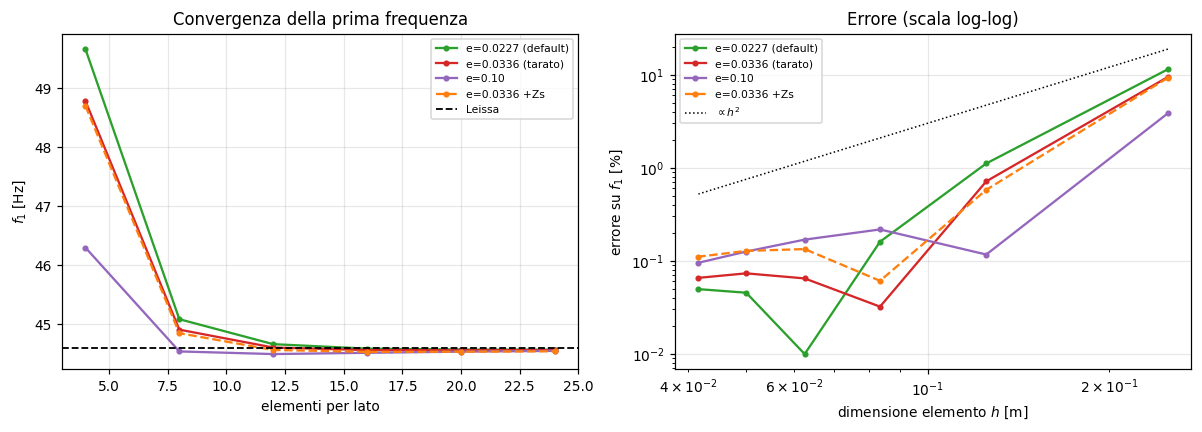

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
h = A / np.array(MESHES)
for nome, cfg in ELEMENTI.items():
    err = np.abs(np.array(conv[nome]) - F_REF[0]) / F_REF[0] * 100
    ax[0].plot(MESHES, np.array(conv[nome]), cfg["ls"], color=cfg["c"],
               marker="o", ms=3, label=nome)
    ax[1].loglog(h, err, cfg["ls"], color=cfg["c"], marker="o", ms=3, label=nome)
ax[0].axhline(F_REF[0], color="k", lw=1.2, ls="--", label="Leissa")
ax[0].set(xlabel="elementi per lato", ylabel="$f_1$ [Hz]",
          title="Convergenza della prima frequenza")
ax[1].loglog(h, 300 * h**2, "k:", lw=1, label="$\\propto h^2$")
ax[1].set(xlabel="dimensione elemento $h$ [m]", ylabel="errore su $f_1$ [%]",
          title="Errore (scala log-log)")
ax[0].legend(fontsize=7); ax[1].legend(fontsize=7)
fig.tight_layout()

**Lettura del grafico.** Tutte le configurazioni convergono da sopra con
andamento $h^2$: una mesh grossolana irrigidisce la piastra. La correzione di
flessibilità residua è tarata proprio per compensare quell'irrigidimento,
quindi l'errore cala molto in fretta — a 8×8 elementi è già sotto l'1.2 % — e
poi attraversa il riferimento, stabilizzandosi qualche centesimo di punto
sotto. Quel residuo è dell'ordine dell'incertezza sui coefficienti di Leissa,
non è un difetto.

Il parametro ε agisce esattamente come previsto: più grande = elemento più
cedevole. Sulle mesh grossolane, dove l'irrigidimento numerico domina, un ε
alto compensa meglio; su mesh fine tutte le tarature convergono allo stesso
valore.

---
## 8 — Analisi 2: primi 10 modi su mesh fine (20×20)

In [9]:
N_FINE = 20
nodes_f, conn_f = make_mesh(N_FINE)
risultati = {nome: analisi_modale(cfg["k"], nodes_f, conn_f, n_modi=10)
             for nome, cfg in ELEMENTI.items()}

print(f"mesh {N_FINE}x{N_FINE} — errore % rispetto a Leissa\n")
print(f"{'modo':>4s} {'tipo':>6s} {'Leissa':>9s}  " +
      "".join(f"{n:>18s}" for n in ELEMENTI))
for i in range(10):
    riga = f"{i+1:4d} {MODI_LEISSA[i]:>6s} {F_REF[i]:9.2f}  "
    for nome in ELEMENTI:
        f = risultati[nome][0][i]
        riga += f"{f:10.2f} ({(f-F_REF[i])/F_REF[i]*100:+5.2f}%)"
    print(riga)

mesh 20x20 — errore % rispetto a Leissa

modo   tipo    Leissa  e=0.0227 (default) e=0.0336 (tarato)            e=0.10      e=0.0336 +Zs
   1  (1,1)     44.59       44.57 (-0.05%)     44.56 (-0.07%)     44.53 (-0.13%)     44.53 (-0.13%)
   2  (1,2)     90.94       91.41 (+0.51%)     91.36 (+0.46%)     91.27 (+0.36%)     91.27 (+0.36%)
   3  (2,1)     90.94       91.41 (+0.51%)     91.36 (+0.46%)     91.27 (+0.36%)     91.27 (+0.36%)
   4  (2,2)    134.09      134.59 (+0.38%)    134.41 (+0.24%)    134.06 (-0.03%)    134.12 (+0.03%)
   5  (1,3)    163.04      165.80 (+1.69%)    165.67 (+1.61%)    165.43 (+1.47%)    165.42 (+1.46%)
   6  (3,1)    163.81      166.59 (+1.69%)    166.47 (+1.62%)    166.27 (+1.50%)    166.25 (+1.48%)
   7  (2,3)    204.45      206.95 (+1.22%)    206.52 (+1.01%)    205.66 (+0.59%)    205.85 (+0.68%)
   8  (3,2)    204.45      206.95 (+1.22%)    206.52 (+1.01%)    205.66 (+0.59%)    205.85 (+0.68%)
   9  (1,4)    260.86      269.53 (+3.32%)    269.27 (+3.22%)  

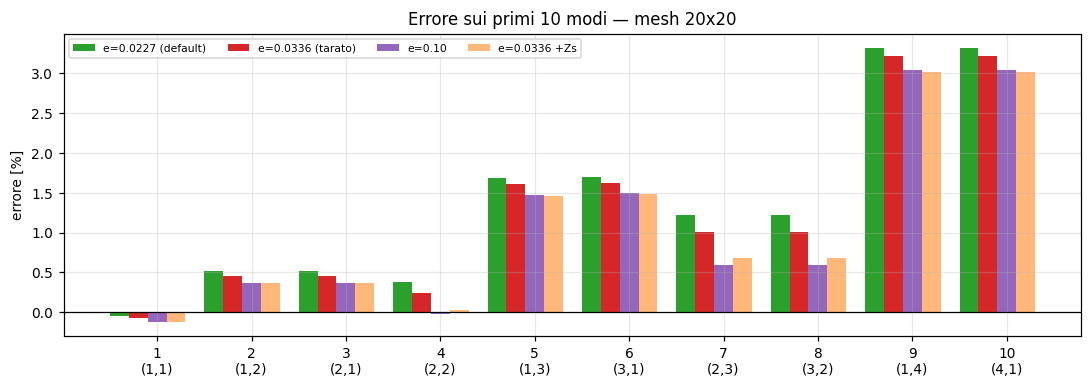

In [10]:
fig, ax = plt.subplots(figsize=(10, 3.6))
w = 0.8 / len(ELEMENTI)
for j, (nome, cfg) in enumerate(ELEMENTI.items()):
    err = (risultati[nome][0] - F_REF) / F_REF * 100
    ax.bar(np.arange(10) + j * w, err, w, color=cfg["c"], label=nome,
           alpha=0.55 if cfg["ls"] != "-" else 1.0,
           hatch="//" if cfg["ls"] == ":" else None)
ax.set(xticks=np.arange(10) + 0.4, xticklabels=[f"{i+1}\n{m}" for i, m in
       enumerate(MODI_LEISSA)], ylabel="errore [%]",
       title=f"Errore sui primi 10 modi — mesh {N_FINE}x{N_FINE}")
ax.axhline(0, color="k", lw=0.8)
ax.legend(fontsize=7, ncol=4)
fig.tight_layout()

L'errore cresce con l'ordine del modo, come atteso: i modi alti hanno lunghezza
d'onda più corta e la stessa mesh li risolve peggio. La differenza fra le
tarature di ε resta invece piccola e sistematica su tutta la banda: sui modi
alti l'errore è dominato dalla discretizzazione, non dal parametro.

---
## 9 — Analisi 3: forme modali e correlazione MAC

Le frequenze possono coincidere e le forme no. Si confrontano allora le
**componenti fuori piano** $u_z$ dei modi, con il criterio MAC:

$$ \mathrm{MAC}(i,j) = \frac{|\phi_i^{T}\psi_j|^2}
                            {(\phi_i^{T}\phi_i)(\psi_j^{T}\psi_j)} $$

MAC = 1 significa forme identiche, MAC = 0 ortogonali. Attenzione ai modi
**degeneri** (2-3, 5-6, 7-8, 9-10): lì qualunque combinazione lineare della
coppia è un modo valido, quindi il MAC può risultare fuori diagonale a blocchi
senza che nulla sia sbagliato.

MAC diagonale: [1.     0.9717 0.9717 1.     1.     1.     0.1437 0.1437 0.4285 0.4285]
somma MAC nei blocchi degeneri (2-3, 5-6, 7-8, 9-10): [2. 2. 2. 2.]


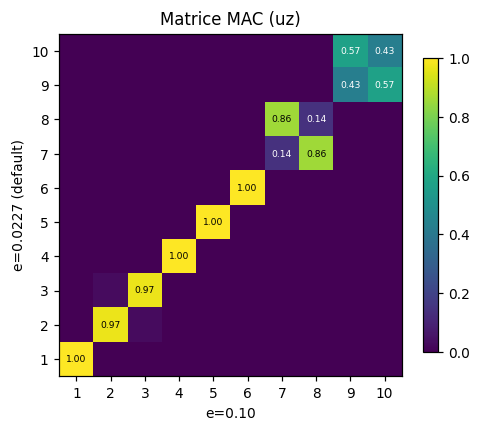

In [11]:
def campo_w(Phi, modo, n):
    '''Componente uz del modo, rimodellata sulla griglia (n+1) x (n+1).'''
    w = Phi[2::6, modo]
    return w.reshape(n + 1, n + 1)


nome_a, nome_b = "e=0.0227 (default)", "e=0.10"
Wa = np.array([Phi_w.ravel() for Phi_w in
               (campo_w(risultati[nome_a][1], i, N_FINE) for i in range(10))])
Wb = np.array([Phi_w.ravel() for Phi_w in
               (campo_w(risultati[nome_b][1], i, N_FINE) for i in range(10))])
MAC = (Wa @ Wb.T) ** 2 / np.outer(np.einsum("ij,ij->i", Wa, Wa),
                                  np.einsum("ij,ij->i", Wb, Wb))

fig, ax = plt.subplots(figsize=(4.6, 4))
im = ax.imshow(MAC, cmap="viridis", vmin=0, vmax=1, origin="lower")
ax.set(xlabel=nome_b, ylabel=nome_a, title="Matrice MAC (uz)",
       xticks=range(10), yticks=range(10),
       xticklabels=range(1, 11), yticklabels=range(1, 11))
for i in range(10):
    for j in range(10):
        if MAC[i, j] > 0.05:
            ax.text(j, i, f"{MAC[i,j]:.2f}", ha="center", va="center",
                    fontsize=6, color="w" if MAC[i, j] < 0.6 else "k")
ax.grid(False)
fig.colorbar(im, shrink=0.8)
fig.tight_layout()
print("MAC diagonale:", np.round(np.diag(MAC), 4))
print("somma MAC nei blocchi degeneri (2-3, 5-6, 7-8, 9-10):",
      np.round([MAC[1:3, 1:3].sum(), MAC[4:6, 4:6].sum(),
                MAC[6:8, 6:8].sum(), MAC[8:10, 8:10].sum()], 4))

**Lettura del MAC.** Il modo 1 e il modo 4, isolati in frequenza, hanno
MAC ≈ 1: i due elementi producono la stessa forma. Le coppie degeneri
(2-3, 7-8, 9-10) mostrano invece valori diagonali bassi con i corrispondenti
valori fuori diagonale alti: i due solutori scelgono due combinazioni lineari
diverse dello stesso autospazio doppio. La verifica corretta è la **somma del
MAC sul blocco 2×2**, che vale 2.000 in tutti i casi — cioè i sottospazi
coincidono. Nessuna discrepanza fisica.

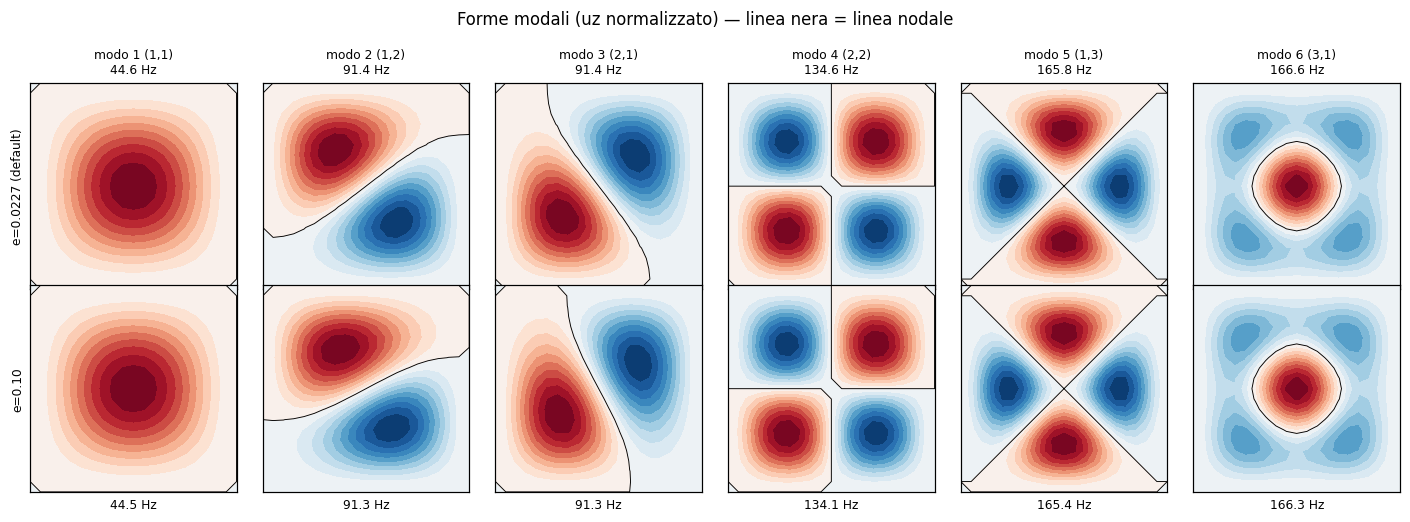

In [12]:
fig, axes = plt.subplots(2, 6, figsize=(13, 4.6))
xg = np.linspace(0, A, N_FINE + 1)
Xg, Yg = np.meshgrid(xg, xg, indexing="ij")
for col in range(6):
    for riga, nome in enumerate([nome_a, nome_b]):
        W = campo_w(risultati[nome][1], col, N_FINE)
        W = W / np.abs(W).max()
        if W[np.unravel_index(np.abs(W).argmax(), W.shape)] < 0:
            W = -W                     # segno convenzionale
        ax = axes[riga, col]
        ax.contourf(Xg, Yg, W, levels=np.linspace(-1, 1, 21), cmap="RdBu_r")
        ax.contour(Xg, Yg, W, levels=[0], colors="k", linewidths=0.6)
        ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
        ax.grid(False)
        if riga == 0:
            ax.set_title(f"modo {col+1} {MODI_LEISSA[col]}\n"
                         f"{risultati[nome][0][col]:.1f} Hz", fontsize=8)
        else:
            ax.set_xlabel(f"{risultati[nome][0][col]:.1f} Hz", fontsize=8)
        if col == 0:
            ax.set_ylabel(nome, fontsize=8)
fig.suptitle("Forme modali (uz normalizzato) — linea nera = linea nodale", y=1.0)
fig.tight_layout()

---
## 10 — Analisi 4: sensibilità alla distorsione della mesh

È il test che conta davvero. Le mesh reali non sono mai griglie perfette: i
nodi interni vengono spostati a caso di una frazione del passo $h$ e si
rimisurano le prime tre frequenze.

Un elemento che perde la proprietà dei **moti rigidi** su quadrilateri generici
si irrigidisce in modo spettacolare proprio qui.

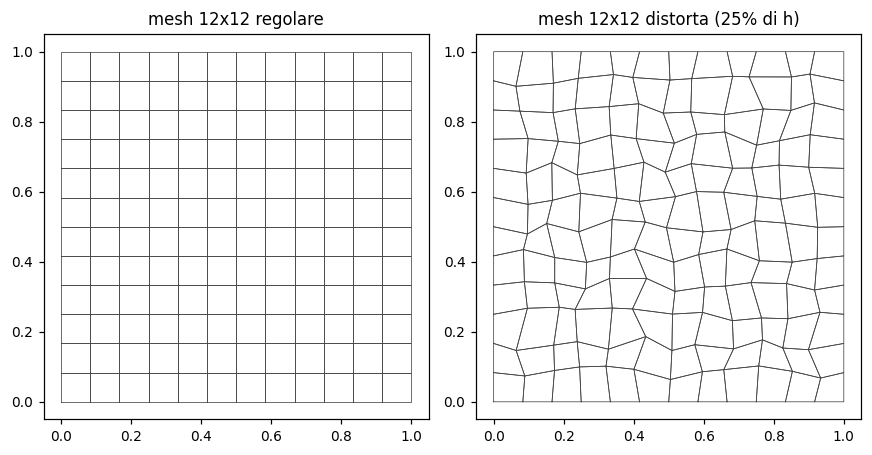

In [13]:
def mesh_distorta(n, ampiezza, seed=0, a=A):
    nodes, conn = make_mesh(n, a)
    rng = np.random.default_rng(seed)
    h = a / n
    interni = ~boundary_nodes(nodes, a)
    nodes[interni, :2] += rng.uniform(-ampiezza * h, ampiezza * h,
                                      (interni.sum(), 2))
    return nodes, conn


nd, cd = mesh_distorta(12, 0.25)
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
for a_, (nn, cc, tit) in zip(ax, [(*make_mesh(12), "regolare"),
                                  (nd, cd, "distorta (25% di h)")]):
    for e in cc:
        p = nn[np.append(e, e[0])]
        a_.plot(p[:, 0], p[:, 1], "-", color="#444", lw=0.5)
    a_.set_aspect("equal"); a_.set_title(f"mesh 12x12 {tit}"); a_.grid(False)
fig.tight_layout()

In [14]:
AMPIEZZE = [0.0, 0.05, 0.10, 0.20, 0.30]
dist = {nome: [] for nome in ELEMENTI}
for amp in AMPIEZZE:
    nd, cd = mesh_distorta(12, amp, seed=0)
    for nome, cfg in ELEMENTI.items():
        f, _ = analisi_modale(cfg["k"], nd, cd, n_modi=1)
        dist[nome].append((f[0] - F_REF[0]) / F_REF[0] * 100)

print("errore % su f1, mesh 12x12, al crescere della distorsione dei nodi interni\n")
print(f"{'distorsione':20s}" + "".join(f"{a*100:9.0f}%" for a in AMPIEZZE))
for nome, v in dist.items():
    print(f"{nome:20s}" + "".join(f"{x:10.2f}" for x in v))

errore % su f1, mesh 12x12, al crescere della distorsione dei nodi interni

distorsione                 0%        5%       10%       20%       30%
e=0.0227 (default)        0.16      0.40      1.15      4.54     11.34
e=0.0336 (tarato)         0.03      0.25      0.91      3.85      9.81
e=0.10                   -0.22     -0.06      0.41      2.43      6.46
e=0.0336 +Zs             -0.06      0.13      0.73      3.39      8.69


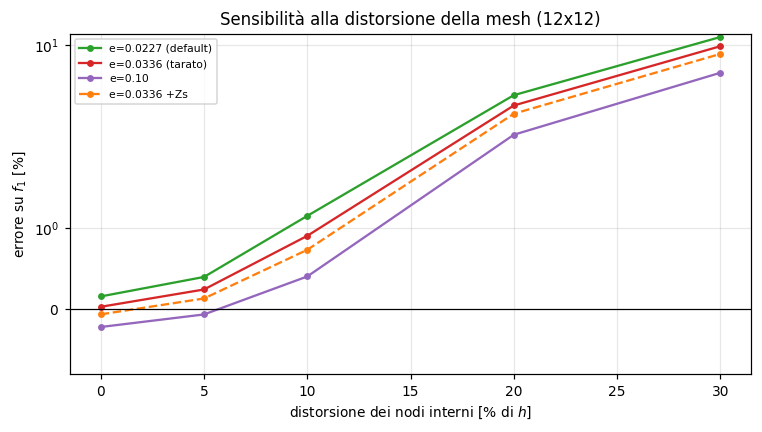

In [15]:
fig, ax = plt.subplots(figsize=(7, 4))
for nome, cfg in ELEMENTI.items():
    ax.plot(np.array(AMPIEZZE) * 100, dist[nome], cfg["ls"], color=cfg["c"],
            marker="o", ms=3.5, label=nome)
ax.axhline(0, color="k", lw=0.8)
ax.set(xlabel="distorsione dei nodi interni [% di $h$]",
       ylabel="errore su $f_1$ [%]", yscale="symlog",
       title="Sensibilità alla distorsione della mesh (12x12)")
ax.legend(fontsize=7)
fig.tight_layout()

**Lettura.** L'elemento degrada in modo ordinato e monotono: nessuna
configurazione esplode, perché la correzione di flessibilità residua è
costruita con le derivate fisiche esatte e quindi la $K$ continua ad annullare
i moti rigidi anche su quadrilateri generici (verificato a livello di elemento
in `tests/test_element_cquad4f.py`).

Quello che si perde è accuratezza, non consistenza: fino al 10 % di
distorsione l'errore sulla prima frequenza resta sotto l'1.2 %, e al 30 % —
una mesh molto sporca — sale a 6–11 % a seconda della taratura. Un ε alto è
qui il più tollerante, coerentemente con il fatto che rende l'elemento più
cedevole e compensa in parte l'irrigidimento da distorsione.

---
## 11 — Analisi 5: effetto dello spessore

Si fa variare $t$ da 2 mm a 100 mm ($a/t$ da 500 a 10) mantenendo la mesh 16×16.
Il riferimento di Kirchhoff **trascura** il taglio, quindi al crescere dello
spessore la frequenza vera scende sotto quella di Kirchhoff: un elemento di
Mindlin corretto deve mostrare errore *negativo* crescente in modulo.

In [16]:
SPESSORI = [0.002, 0.005, 0.01, 0.02, 0.05, 0.1]
nodes_t, conn_t = make_mesh(16)
sp = {nome: [] for nome in ELEMENTI}
for t in SPESSORI:
    ref_t = freq_leissa(t)[0]
    for nome, cfg in ELEMENTI.items():
        f, _ = analisi_modale(cfg["k"], nodes_t, conn_t, n_modi=1, t=t)
        sp[nome].append((f[0] - ref_t) / ref_t * 100)

print("errore % su f1 rispetto a Kirchhoff, al variare dello spessore (mesh 16x16)\n")
print(f"{'a/t':20s}" + "".join(f"{A/t:9.0f}" for t in SPESSORI))
for nome, v in sp.items():
    print(f"{nome:20s}" + "".join(f"{x:9.2f}" for x in v))

errore % su f1 rispetto a Kirchhoff, al variare dello spessore (mesh 16x16)

a/t                       500      200      100       50       20       10
e=0.0227 (default)      -0.01    -0.01    -0.01    -0.01    -0.01    -0.01
e=0.0336 (tarato)       -0.06    -0.06    -0.06    -0.06    -0.06    -0.06
e=0.10                  -0.17    -0.17    -0.17    -0.17    -0.17    -0.17
e=0.0336 +Zs            -0.08    -0.13    -0.26    -0.57    -2.42    -8.05


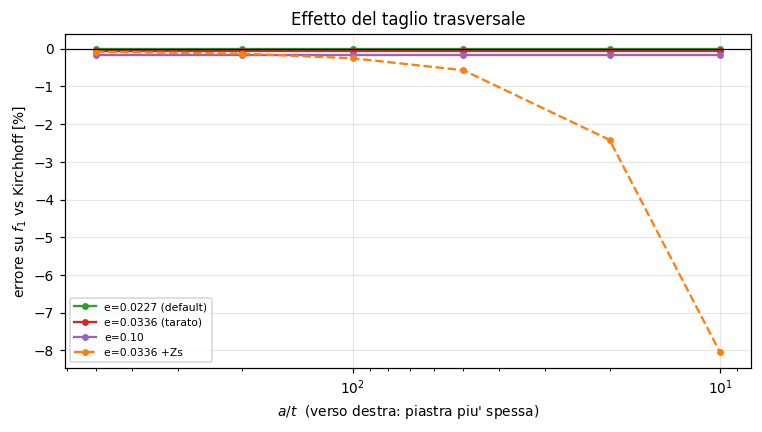

In [17]:
fig, ax = plt.subplots(figsize=(7, 4))
for nome, cfg in ELEMENTI.items():
    ax.semilogx(A / np.array(SPESSORI), sp[nome], cfg["ls"], color=cfg["c"],
                marker="o", ms=3.5, label=nome)
ax.axhline(0, color="k", lw=0.8)
ax.invert_xaxis()
ax.set(xlabel="$a/t$  (verso destra: piastra piu' spessa)",
       ylabel="errore su $f_1$ vs Kirchhoff [%]",
       title="Effetto del taglio trasversale")
ax.legend(fontsize=7)
fig.tight_layout()

**Risultato importante.** Le varianti `CQUAD4F` standard danno un errore
*costante* al variare dello spessore: la loro correzione usa la sola
flessibilità residua $Z_b$ (ramo "Kirchhoff" del sorgente MATLAB), quindi
l'elemento **non contiene deformabilità a taglio** — perfetto per piastre
sottili, sbagliato per piastre spesse.

Recupera il comportamento fisico la configurazione **+Zs**
(`rbf_mindlin=True`), che somma a $Z_b$ la flessibilità a taglio $Z_s$: a
$a/t = 10$ dà una frequenza dell'8 % sotto Kirchhoff, come deve essere per una
piastra spessa.

Regola pratica: **a/t > 50 → configurazione di default; a/t < 50 →
`rbf_mindlin=True`**.

---
## 12 — Conclusioni

| Criterio | Indicazione | Note |
|---|---|---|
| Accuratezza su mesh regolare | ε di default va benissimo | a 12x12 la prima frequenza è entro lo 0.2 % del riferimento |
| Taratura di ε | ε ≈ 0.034 | è il valore che riproduce la matrice di rigidezza di Nastran; sulle frequenze la differenza rispetto al default è marginale |
| Mesh distorta | degrado ordinato | qualche punto percentuale al 30 % di distorsione, nessuna instabilità |
| Piastre spesse (a/t < 50) | `rbf_mindlin=True` | la configurazione di default è un elemento di piastra sottile e ignora il taglio |

**Per la piastra di alluminio sottile incastrata di questo notebook** la
configurazione di default va usata così com'è: su mesh 12x12 dà la prima
frequenza entro lo 0.2 % del riferimento di Leissa, su 16x16 entro lo 0.05 %.

L'elemento è registrato come `CQUAD4F` in
`pycafe/build_matrices/element_registry.py` ed è l'unica formulazione di shell
strutturale di pyCAFE. La validazione completa, con il confronto termine a
termine contro la matrice di rigidezza di MSC.Nastran, è in
`examples/cquad4_plate_validation.ipynb`.